In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
# df = pd.read_csv('run2025_none.csv')
df = pd.read_csv('Pb_labeled.csv')

GRtiming = df['GRQ2timing']
LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

In [28]:
#p,α,トラッキング、コインシデンスゲート
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

gated_208Pb = tracking_gated[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]
gated_208Pb_GRQ2timing = gated_208Pb['GRQ2timing']
gated_208Pb_LASQ1timing = gated_208Pb['LASQ1timing']
gated_208Pb_GRX = gated_208Pb["GRX"]

# TDiff = gated_208Pb_LASQ1timing - gated_208Pb_GRQ2timing
TDiff = gated_208Pb_GRQ2timing - gated_208Pb_LASQ1timing

mean = 86.947
sigma = 3.377

#true coincidenceのみ抽出
true_208Pb = gated_208Pb[
    (TDiff >= mean - 5 * sigma) & (TDiff <= mean + 5 * sigma)
]

#　コインシデンスとったやつのみ抽出
GRX_true = true_208Pb['GRX']
LASX_true = true_208Pb['LASX']
LASA_true = true_208Pb['LASA']
GRQ2timing_true = true_208Pb['GRQ2timing']
LASQ1timing_true = true_208Pb['LASQ1timing']

#Tp, Tαを再構成
# シリーズのまま一括計算
Tp = (((GRX_true * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha = 0.02746 * LASX_true + 63.804

In [29]:
len(true_208Pb)

14786

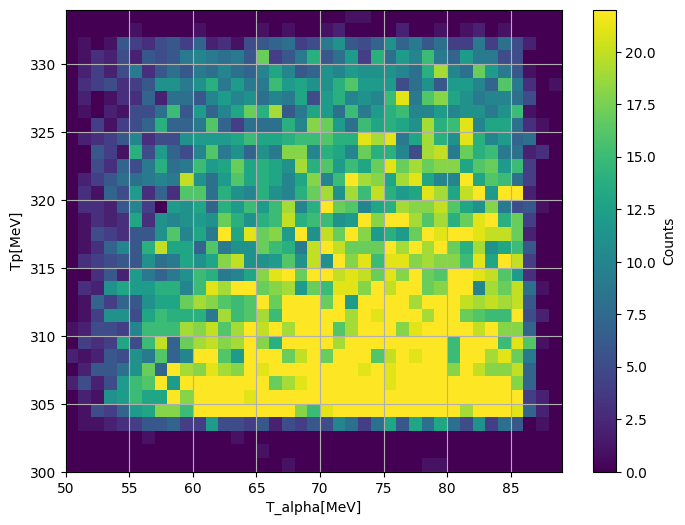

In [30]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=T_alpha
y_axis_variable=Tp
#hist range
x_axis_range_min = 50
x_axis_range_max = 90
y_axis_range_min = 300
y_axis_range_max = 335
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('T_alpha[MeV]')
ax.set_ylabel('Tp[MeV]')
ax.grid()

Text(0, 0.5, 'counts')

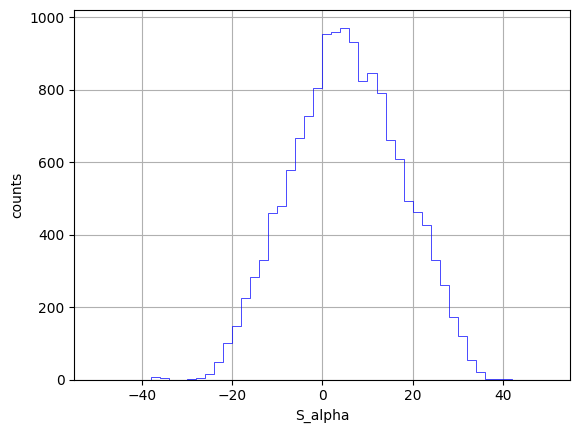

In [31]:
# リスト内包表記で各要素を足し算
# S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]
S_alpha = 392 - Tp - T_alpha

variables = S_alpha

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=2

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')

In [32]:
Tp = (((GRX_true * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha = 0.02746 * LASX_true + 63.804

#新しくLASXを調整する。

# A = -1.792
# B = 1014.152

A = -2.57
B = 1274.57

alpha = 0.02746
beta = 63.804

# LASX_true_f = LASA_true * (A * (alpha * GRX_true + beta) + B) + LASX_true
LASX_true_f = LASA_true * (A * Tp + B) + LASX_true

T_alpha_f = 0.02746 * LASX_true_f + 63.804

print(T_alpha)
print(T_alpha_f)

11         57.409307
224        82.346914
333        63.829107
810        61.064036
1201       77.575382
             ...    
2237348    71.594649
2237623    86.414097
2237981    59.065914
2239112    53.733237
2239391    78.036518
Name: LASX, Length: 14786, dtype: float64
11         58.937575
224        83.385314
333        63.958184
810        60.974717
1201       77.082089
             ...    
2237348    71.075384
2237623    87.290361
2237981    56.522693
2239112    50.429574
2239391    80.910359
Length: 14786, dtype: float64


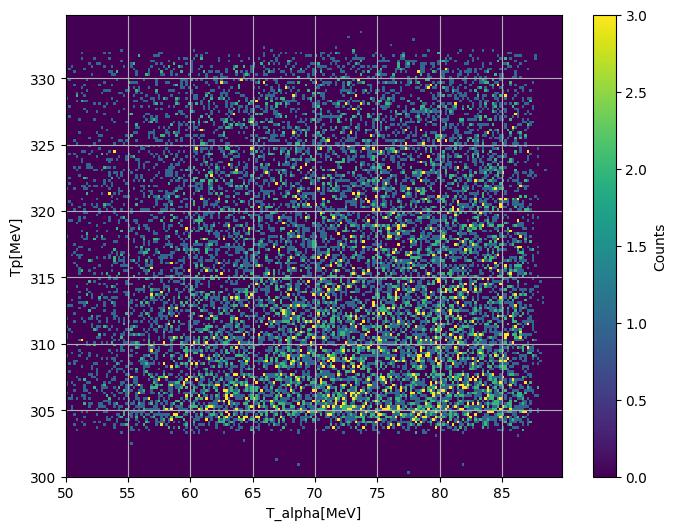

In [33]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=T_alpha_f
y_axis_variable=Tp
#hist range
x_axis_range_min = 50
x_axis_range_max = 90
y_axis_range_min = 300
y_axis_range_max = 335
#bin width
x_bin_width=0.2
y_bin_width=0.2
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('T_alpha[MeV]')
ax.set_ylabel('Tp[MeV]')
ax.grid()

Text(0, 0.5, 'counts')

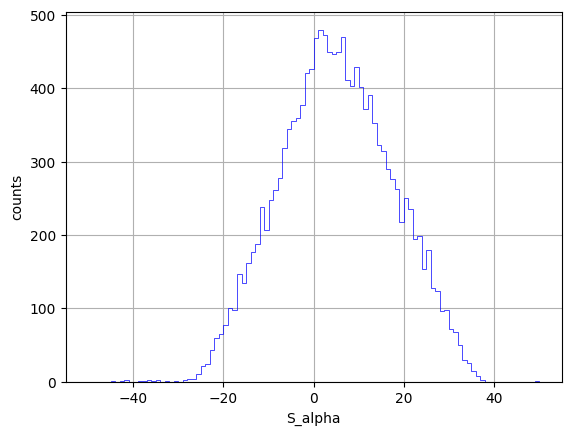

In [34]:
# リスト内包表記で各要素を足し算
# S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]
S_alpha = 392 - Tp - T_alpha_f

variables = S_alpha

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')